# Дискретизировать (можно использовать numpy.round()) пространство состояний и обучить Агента решать CartPole-v1, Acrobot-v1, MountainCar-v0, или LunarLander-v2 (одну на выбор) методами Monte Carlo, SARSA и Q-Learning. Сравнить результаты этих алгоритмов и реализованного ранее алгоритма Deep Cross-Entropy на графиках. 

# Libs

In [1]:
from typing import Any, Optional
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import gym
from gym import Env

# Agent

In [2]:
class Agent:
    def __init__(self, env: Env):
        self.env = env
        self.observation_space = env.observation_space.n
        self.action_space = env.action_space.n
        self.Q = np.zeros((self.observation_space, self.action_space))
        
    def reset(self):
        self.Q = np.zeros((self.observation_space, self.action_space))
        
    @staticmethod
    def plot(rewards: list[int | float], steps: int, label: str) -> None:
        fig, ax1 = plt.subplots()        
        ax1.plot(steps, color="b", label="Trajectory lengths", linewidth=0.5)
        ax1.set_xlabel("Trajectory number/Iteration")
        ax1.set_ylabel("Steps", color="b")
        ax1.tick_params(axis="y", labelcolor="b")
        ax1.legend(loc="upper left")
        
        ax2 = ax1.twinx()        
        ax2.plot(rewards, color="r", label="Rewards", linewidth=0.5)
        ax2.set_ylabel("Total Reward", color="r")
        ax2.tick_params(axis="y", labelcolor="r")
        ax2.legend(loc="upper right")
        
        plt.title(f" {label}: Steps and Rewards per Trajectory")        
        plt.show()

    def get_action(self, 
                   state: Any,
                   eps: Optional[float] = .0
                   ) -> int:
        probs = np.full(self.action_space, eps / self.action_space)
        greedy_action = np.argmax(self.Q[state])
        probs[greedy_action] += 1 - eps
        return np.random.choice(self.action_space, p=probs)
    
    def get_trajectory(self, eps: Optional[float] = None):
        done = False
        trajectory = {
            "states": [], 
            "actions": [], 
            "rewards": [],
        }
        
        state = self.env.reset()
        while not done:
            trajectory["states"].append(state)
            action = self.get_action(state, eps)
            trajectory["actions"].append(action)
            state, reward, done, _ = env.step(action)
            trajectory["rewards"].append(reward)
        return trajectory
    
    @staticmethod
    def exponential_decay(start: float, end: float, eps: float) -> float:
        return start * (end / start) ** eps
    
    @staticmethod
    def linear_decay(start: float, end: float, eps: float) -> float:
        return start + (end - start) * eps    
        
    def monte_carlo(self, 
                    num_trajectories: int,
                    eps_start: float = 1.0, 
                    eps_end: float = 0.1,
                    gamma: float = 0.99,
                    plot: bool = True
                    ):
        rewards_per_trajectory = []
        steps_per_trajectory = []
        counter = np.zeros((self.observation_space, self.action_space))
        
        for i in tqdm(range(num_trajectories), desc="Monte Carlo"):
            eps = i / num_trajectories
            eps = self.exponential_decay(eps_start, eps_end, eps)
            trajectory = self.get_trajectory(eps)
            
            # Catch statistics
            total_reward = sum(trajectory["rewards"])
            rewards_per_trajectory.append(total_reward)
            real_trajectory_len = len(trajectory["rewards"])
            steps_per_trajectory.append(real_trajectory_len)
            
            # Compute returns 
            returns = np.zeros(real_trajectory_len + 1)
            for t in range(real_trajectory_len - 1, -1, -1):
                returns[t] = trajectory["rewards"][t] + gamma * returns[t + 1]
            returns = returns[:-1]
            
            # Update Q function
            for state, action, G in zip(trajectory["states"], trajectory["actions"], returns):
                counter[state][action] += 1
                self.Q[state][action] += (G - self.Q[state][action]) / counter[state][action]
        
        if plot:
            self.plot(
                rewards_per_trajectory, 
                steps_per_trajectory, 
                label="Mote Carlo"
            )
            
        return {
            "rewards_per_trajectory": rewards_per_trajectory, 
            "steps_per_trajectory": steps_per_trajectory
        }
    
    def sarsa(self, 
              num_trajectories: int,
              eps_start: float = 1.0, 
              eps_end: float = 0.1,
              gamma: float = 0.99,
              lr_start: float = 0.1,
              lr_end: float = 0.5,
              plot: bool = True
              ):
        rewards_per_trajectory = []
        steps_per_trajectory = []
        
        for i in tqdm(range(num_trajectories), desc="SARSA"):
            rewards = 0
            steps = 0
            done = False
            eps = self.exponential_decay(
                eps_start, eps_end,  i / num_trajectories
            )
            lr = self.linear_decay(
                lr_start, lr_end, i / num_trajectories
            )
            
            state = self.env.reset()
            action = self.get_action(state, eps)
            while not done:
                next_state, reward, done, _ = self.env.step(action)
                next_action = self.get_action(state, eps)
                rewards += reward
                steps += 1
                
                self.Q[state][action] += lr * (reward + gamma * self.Q[next_state][next_action] - self.Q[state][action])    
                state = next_state
                action = next_action
            
            rewards_per_trajectory.append(rewards)
            steps_per_trajectory.append(steps)

        if plot:
            self.plot(
                rewards_per_trajectory, 
                steps_per_trajectory, 
                label="SARSA"
            )
            
        return {
            "rewards_per_trajectory": rewards_per_trajectory, 
            "steps_per_trajectory": steps_per_trajectory
        }
    
    def q_learning(self, 
              num_trajectories: int,
              eps_start: float = 1.0, 
              eps_end: float = 0.1,
              gamma: float = 0.99,
              lr_start: float = 0.1,
              lr_end: float = 0.5,
              plot: bool = True
              ):
        rewards_per_trajectory = []
        steps_per_trajectory = []
        
        for i in tqdm(range(num_trajectories), desc="SARSA"):
            rewards = 0
            steps = 0
            done = False
            eps = self.exponential_decay(
                eps_start, eps_end,  i / num_trajectories
            )
            lr = self.linear_decay(
                lr_start, lr_end, i / num_trajectories
            )
            
            state = env.reset()
            while not done:
                action = self.get_action(state, eps) 
                next_state, reward, done, _ = env.step(action)
                rewards += reward
                steps += 1
                
                self.Q[state][action] += lr * (reward + gamma * self.Q[next_state].max() - self.Q[state][action])    
                state = next_state
                
            rewards_per_trajectory.append(rewards)
            steps_per_trajectory.append(steps)

        if plot:
            self.plot(
                rewards_per_trajectory, 
                steps_per_trajectory, 
                label="SARSA"
            )
            
        return {
            "rewards_per_trajectory": rewards_per_trajectory, 
            "steps_per_trajectory": steps_per_trajectory
        }

# Env

In [4]:
num_trajectories: int = 10_000
eps_start: float = .5
eps_end: float = .0
gamma: float = 0.99
lr_start = .1
lr_end = .5

env = gym.make("CartPole-v1")
#agent = Agent(env)

In [19]:
def discretize(value, decimals=1):
    return round(value, decimals)

def get_discrete_state(state, decimals=1):
    if isinstance(state, np.ndarray):
        return tuple(discretize(s, decimals) for s in state)
    return discretize(state, decimals)

def get_discrete_action(action, decimals=1):
    if isinstance(action, np.ndarray):
        return tuple(discretize(a, decimals) for a in action)
    return discretize(action, decimals)

In [18]:
env.reset()

array([-0.00654136, -0.00176715,  0.01101177,  0.04642098], dtype=float32)

In [35]:
get_discrete_state(env.reset())

(-0.0, 0.0, 0.0, 0.0)

## Monte carlo

Monte Carlo:   0%|          | 0/10000 [00:00<?, ?it/s]

/home/merci/code/PycharmProjects/deep-RL/.venv/lib/python3.11/site-packages/gym/utils/passive_env_checker.py:241: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
/home/merci/code/PycharmProjects/deep-RL/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


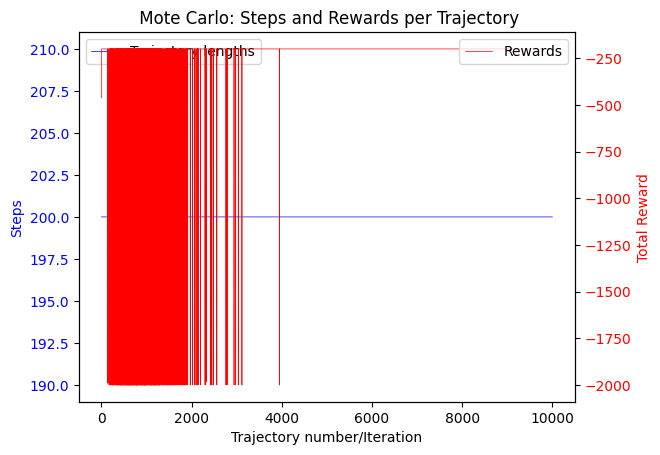

{'rewards_per_trajectory': [-461,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200,
  -200

In [5]:
agent.monte_carlo(num_trajectories, eps_start, eps_end, gamma)

## SARSA

SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

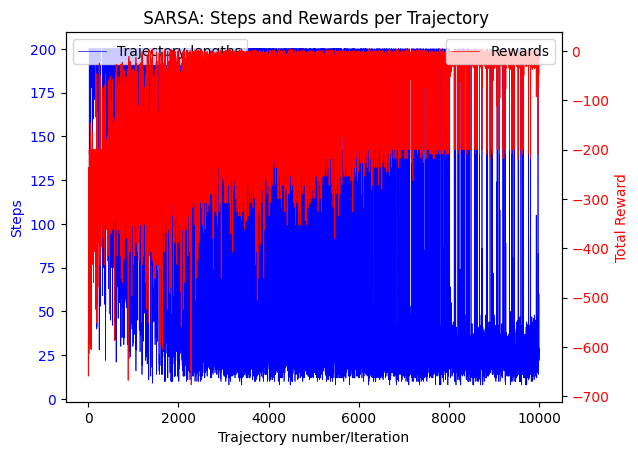

{'rewards_per_trajectory': [-587,
  -596,
  -659,
  -299,
  -605,
  -659,
  -641,
  -605,
  -641,
  -443,
  -299,
  -335,
  -614,
  -506,
  -272,
  -596,
  -236,
  -614,
  -263,
  -416,
  -497,
  -272,
  -200,
  -209,
  -409,
  -200,
  -479,
  -290,
  -236,
  -236,
  -353,
  -200,
  -344,
  -398,
  -317,
  -326,
  -326,
  -227,
  -335,
  -416,
  -308,
  -398,
  -263,
  -272,
  -218,
  -236,
  -569,
  -344,
  -272,
  -474,
  -362,
  -147,
  -200,
  -596,
  -308,
  -326,
  -362,
  -317,
  -200,
  -605,
  -389,
  -200,
  -245,
  -335,
  -281,
  -200,
  -272,
  -362,
  -281,
  -245,
  -425,
  -245,
  -200,
  -328,
  -398,
  -245,
  -605,
  -200,
  -236,
  -425,
  -281,
  -308,
  -254,
  -200,
  -254,
  -299,
  -200,
  -272,
  -183,
  -218,
  -416,
  -200,
  -200,
  -200,
  -164,
  -432,
  -290,
  -281,
  -200,
  -236,
  -335,
  -299,
  -227,
  -218,
  -200,
  -200,
  -326,
  -218,
  -200,
  -434,
  -299,
  -290,
  -236,
  -245,
  -254,
  -281,
  -200,
  -371,
  -470,
  -308,
  -200,
  -236

In [6]:
agent.reset()
agent.sarsa(num_trajectories, eps_start, eps_end, gamma, lr_start, lr_end)

# Q-learning

SARSA:   0%|          | 0/10000 [00:00<?, ?it/s]

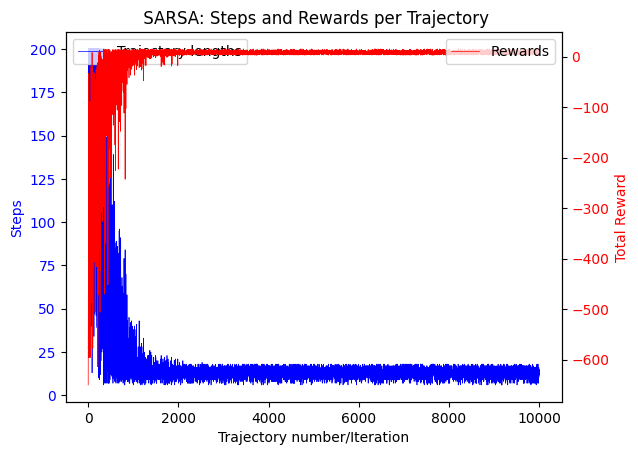

{'rewards_per_trajectory': [-650,
  -524,
  -524,
  -470,
  -542,
  -488,
  -542,
  -524,
  -200,
  -542,
  -407,
  -33,
  -200,
  -236,
  -362,
  -181,
  -389,
  -200,
  -200,
  -596,
  -524,
  -407,
  -261,
  -380,
  -560,
  -114,
  -497,
  -200,
  -524,
  -470,
  -317,
  -200,
  -308,
  -200,
  -200,
  -200,
  -200,
  -89,
  -200,
  -272,
  -200,
  -200,
  -200,
  -596,
  -209,
  -200,
  -188,
  -272,
  -200,
  -452,
  -96,
  -338,
  -263,
  -290,
  -200,
  -143,
  -254,
  -290,
  -290,
  -200,
  -209,
  -488,
  -19,
  -218,
  -200,
  -434,
  -281,
  -200,
  -254,
  -200,
  -174,
  -397,
  -290,
  -209,
  -200,
  -299,
  -200,
  -144,
  -200,
  -416,
  -200,
  -145,
  -344,
  -362,
  -169,
  -488,
  8,
  -209,
  -271,
  -200,
  -23,
  -236,
  -326,
  -263,
  -209,
  -290,
  -470,
  -107,
  -200,
  -108,
  -101,
  -343,
  -578,
  -200,
  -178,
  -279,
  -209,
  -249,
  -298,
  -200,
  -326,
  -142,
  -389,
  -168,
  -177,
  -200,
  -200,
  -290,
  -200,
  -245,
  -416,
  -200,
  -200

In [7]:
agent.reset()
agent.q_learning(num_trajectories, eps_start, eps_end, gamma, lr_start, lr_end)